In [1]:
import ctypes
import os
from pathlib import Path

from tqdm.auto import tqdm
import pandas as pd
import torch
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util as st_util

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset
from neurovlm.evaluation.notebook_utils import resolve_evaluation_output_dir
from neurovlm.metrics.brain_to_text import (
    generated_text_metric_summary,
    generated_text_pair_baseline,
    project_brain_latents_to_shared,
    project_text_latents_to_shared,
)

# Optional workaround for environments that need explicit CUDA runtime loading.
cuda_lib = os.environ.get("NEUROVLM_CUDA_LIBRARY_DIR")
if cuda_lib:
    cuda_lib = Path(cuda_lib)
    ctypes.CDLL(str(cuda_lib / "libnvrtc-builtins.so.13.0"), mode=ctypes.RTLD_GLOBAL)
    ctypes.CDLL(str(cuda_lib / "libnvrtc.so.13"), mode=ctypes.RTLD_GLOBAL)

evaluation_output_dir = resolve_evaluation_output_dir()
evaluation_output_dir.mkdir(parents=True, exist_ok=True)

GENERATION_SOURCE = "baseline"  # "qformer_grounded_permissive_epoch29"

GENERATION_SOURCES = {
    "baseline": {
        "path": evaluation_output_dir / "df_gen.parquet",
        "mode": "generated",
        "cache_prefix": "baseline",
    },
    "qformer_grounded_permissive_epoch29": {
        "path": evaluation_output_dir / "df_gen_qformer_grounded_permissive_neuro_epoch-29.parquet",
        "mode": "qformer_grounded_permissive_epoch29",
        "cache_prefix": "qformer_grounded_permissive_epoch29",
    },
}
if GENERATION_SOURCE not in GENERATION_SOURCES:
    raise ValueError(f"Unknown GENERATION_SOURCE={GENERATION_SOURCE!r}; choose one of {list(GENERATION_SOURCES)}")
GENERATION_CONFIG = GENERATION_SOURCES[GENERATION_SOURCE]


def generation_cache_path(filename):
    filename = evaluation_output_dir / Path(filename).name
    if GENERATION_CONFIG["cache_prefix"] == "baseline":
        return filename
    return filename.with_name(f"{GENERATION_CONFIG['cache_prefix']}_{filename.name}")


def generation_output_dir(dirname):
    dirname = evaluation_output_dir / Path(dirname).name
    if GENERATION_CONFIG["cache_prefix"] == "baseline":
        return dirname
    return dirname.with_name(f"{dirname.name}_{GENERATION_CONFIG['cache_prefix']}")

In [2]:
# Load data
images, pmids = load_dataset("pubmed_images")
df_pubs = load_dataset("pubmed_text")

USE_SUMMARY = True
if USE_SUMMARY:
    df_summaries = load_dataset("pubmed_summaries")
    df_pubs["description"] = df_summaries["summary"].str.strip("\n").str.strip(" \n").tolist()

df_pubs_test = df_pubs[df_pubs["test"]].copy()
pub_lookup = df_pubs_test.drop_duplicates("pmid").set_index("pmid", drop=False)

m = pd.Series(pmids).isin(pub_lookup.index).to_numpy()
pmids = pmids[m]
images = images[m]
aligned_pubs = pub_lookup.loc[pmids].reset_index(drop=True)
assert aligned_pubs["pmid"].astype(str).tolist() == pd.Series(pmids).astype(str).tolist()

/tmp/ipykernel_2955/2001904366.py:15: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  images = images[m]


In [3]:
nvlm = NeuroVLM(device="cuda")
if GENERATION_SOURCE not in GENERATION_SOURCES:
    raise ValueError(f"Unknown GENERATION_SOURCE={GENERATION_SOURCE!r}; choose one of {list(GENERATION_SOURCES)}")
GENERATION_CONFIG = GENERATION_SOURCES[GENERATION_SOURCE]
GENERATION_PATH = GENERATION_CONFIG["path"]
GENERATION_MODE = GENERATION_CONFIG["mode"]
RECOMPUTE = False

if GENERATION_SOURCE == "baseline":
    if not GENERATION_PATH.exists() or RECOMPUTE:
        outputs_network = []
        outputs_region = []
        outputs_function = []

        gen_batch_size = 512

        for start in tqdm(range(0, images.shape[0], gen_batch_size), total=len(images) // gen_batch_size):
            for basis in ["network", "region", "function"]:
                batch = images[start : start + gen_batch_size]
                out = nvlm.generate_text(
                    batch,
                    seed=123 + start,
                    basis=basis,
                    do_sample=False,
                    num_beams=1,
                    max_new_tokens=128,
                    projection_temp=0.035,
                    repetition_penalty=1.25,
                )
                out = [out] if isinstance(out, str) else out
                match basis:
                    case "network":
                        outputs_network.extend(out)
                    case "region":
                        outputs_region.extend(out)
                    case "function":
                        outputs_function.extend(out)

        df_gen = pd.DataFrame(dict(
            pmid=pd.Series(pmids).astype(str).tolist(),
            network=outputs_network,
            region=outputs_region,
            function=outputs_function,
        ))
        for k in ["network", "region", "function"]:
            df_gen[k] = df_gen[k].str.replace(".*]", "", regex=True).str.replace("\n\n", "\n", regex=True)
        df_gen["text"] = df_gen["network"] + " [SEP] " + df_gen["region"] + " [SEP] " + df_gen["function"]
        df_gen.to_parquet(GENERATION_PATH)
    else:
        df_gen = pd.read_parquet(GENERATION_PATH).reset_index(drop=True)
elif GENERATION_SOURCE == "qformer_grounded_permissive_epoch29":
    if not GENERATION_PATH.exists():
        raise FileNotFoundError(
            f"{GENERATION_PATH} does not exist. Run the final qformer generation cell first, "
            "or set GENERATION_SOURCE='baseline'."
        )
    df_gen = pd.read_parquet(GENERATION_PATH).reset_index(drop=True)
else:
    raise ValueError(f"Unhandled GENERATION_SOURCE={GENERATION_SOURCE!r}")

if "text" not in df_gen.columns:
    raise ValueError(f"{GENERATION_PATH} must contain a 'text' column")
if len(df_gen) != len(pmids):
    raise ValueError(f"{GENERATION_PATH} has {len(df_gen)} rows but pmids has {len(pmids)} rows")
if "pmid" in df_gen.columns:
    expected_pmids = pd.Series(pmids).astype(str).tolist()
    observed_pmids = df_gen["pmid"].astype(str).tolist()
    if observed_pmids != expected_pmids:
        raise ValueError(f"{GENERATION_PATH} PMID order does not match aligned pmids")
elif GENERATION_SOURCE != "baseline":
    raise ValueError(f"{GENERATION_PATH} must contain a 'pmid' column for alignment checks")

print(f"Using generation source: {GENERATION_SOURCE} ({len(df_gen):,} rows) from {GENERATION_PATH}")


Using generation source: baseline (2,987 rows) from df_gen.parquet


## Metrics

In [4]:
nvlm = NeuroVLM(device="cuda")
if len(df_gen) != len(aligned_pubs):
    raise ValueError(f"df_gen has {len(df_gen)} rows but aligned_pubs has {len(aligned_pubs)} rows.")
truth = (
    aligned_pubs["name"].fillna("").astype(str)
    + " [SEP] "
    + aligned_pubs["description"].fillna("").astype(str)
).tolist()
generated = df_gen["text"].tolist()


In [5]:
# 1. Convert flat brain maps to 384-d autoencoder latents if needed.
def encode_brains_to_latents(nvlm, X, batch_size=256):
    X = torch.as_tensor(X, dtype=torch.float32)
    if X.shape[1] == 384:
        return X.cpu()

    chunks = []
    for start in range(0, len(X), batch_size):
        chunks.append(nvlm._encode_brain_flat(X[start:start + batch_size]).detach().cpu())
    return torch.cat(chunks, dim=0)

brain_latents = encode_brains_to_latents(nvlm, images)

In [6]:
# 2. Text-vs-text metrics.
bert_p_path = generation_cache_path("bert_p.pt")
bert_r_path = generation_cache_path("bert_r.pt")
bert_f1_path = generation_cache_path("bert_f1.pt")

if not all(path.exists() for path in [bert_p_path, bert_r_path, bert_f1_path]) or RECOMPUTE:
    bert_p, bert_r, bert_f1 = bert_score(
        cands=generated,
        refs=truth,
        lang="en",
        model_type="microsoft/deberta-xlarge-mnli",
        verbose=True,
        batch_size=32,
        device="cuda",
    )
    torch.save(bert_p, bert_p_path)
    torch.save(bert_r, bert_r_path)
    torch.save(bert_f1, bert_f1_path)
else:
    bert_p = torch.load(bert_p_path)
    bert_r = torch.load(bert_r_path)
    bert_f1 = torch.load(bert_f1_path)


In [7]:
sem_sim_path = generation_cache_path("sem_sim.pt")
if not sem_sim_path.exists() or RECOMPUTE:
    st_model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")
    g_emb = st_model.encode(generated, convert_to_tensor=True, device="cuda", batch_size=32)
    t_emb = st_model.encode(truth, convert_to_tensor=True, device="cuda", batch_size=32)
    sem_sim = st_util.cos_sim(g_emb, t_emb).diagonal().cpu()
    semantic_embedding_generation_source = GENERATION_SOURCE
    torch.save(sem_sim, sem_sim_path)
else:
    sem_sim = torch.load(sem_sim_path)


In [8]:
def encode_text_batched(nvlm, texts, batch_size=32):
    chunks = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        with torch.no_grad():
            chunks.append(nvlm._encode_text(batch).detach().cpu())
    return torch.cat(chunks, dim=0)

nvlm_sim_path = generation_cache_path("nvslm_sim.pt")
if not nvlm_sim_path.exists() or RECOMPUTE:

    # 3. NeuroVLM contrastive similarity: generated text <-> source brain.
    text_latents = encode_text_batched(nvlm, generated, batch_size=32)
    text_latents_generation_source = GENERATION_SOURCE

    z_text = project_text_latents_to_shared(
        nvlm,
        text_latents,
        batch_size=32,
    )

    z_brain = project_brain_latents_to_shared(
        nvlm,
        brain_latents,
        batch_size=32,
    )
    projected_generation_source = GENERATION_SOURCE

    nvlm_sim = (z_text * z_brain).sum(dim=1)
    torch.save(nvlm_sim, nvlm_sim_path)
else:
    nvlm_sim = torch.load(nvlm_sim_path)


In [9]:
# 4. Build b2t_all.
ids = pd.Series(pmids).astype(str).tolist()

b2t_all = pd.DataFrame({
    "dataset": "pubmed",
    "mode": GENERATION_MODE,
    "name": ids,
    "pmid": ids,
    "generated": generated,
    "gt_text": truth,
    "bert_p": bert_p.cpu().numpy(),
    "bert_r": bert_r.cpu().numpy(),
    "bert_f1": bert_f1.cpu().numpy(),
    "sem_sim": sem_sim.numpy(),
    "nvlm_sim": nvlm_sim.numpy(),
})

# 5. Build the lookup object used by generated_text_metric_summary().
pubmed_eval = [
    {"pmid": sample_id, "latent": latent}
    for sample_id, latent in zip(ids, brain_latents)
]


In [10]:

if ("text_latents" not in globals() or
    len(text_latents) != len(generated) or
    globals().get("text_latents_generation_source") != GENERATION_SOURCE or
    RECOMPUTE
):
    text_latents = encode_text_batched(nvlm, generated, batch_size=32)
    text_latents_generation_source = GENERATION_SOURCE

summary, recall_auc_df, recall_curve_df, label_summary = generated_text_metric_summary(
    nvlm=nvlm,
    b2t_all=b2t_all,
    networks_data={},
    pubmed_eval=pubmed_eval,
    neurovault_eval=[],
    output_dir=generation_output_dir("outputs/b2t_metrics"),
    text_latents=text_latents,
)


There are adapters available but none are activated for the forward pass.


In [11]:
display(summary)
display(recall_auc_df.round(3))
if len(label_summary):
    display(label_summary)

nvlm_sim              bert_f1              sem_sim         \
                      mean    std count    mean    std count    mean    std   
dataset mode                                                                  
pubmed  generated    0.266  0.092  2987   0.557  0.023  2987   0.469  0.122   

                         
                  count  
dataset mode             
pubmed  generated  2987

,dataset,mode,generated_text_normalized_k_recall_curve_auc,n
0,pubmed,generated,0.94,2987


In [12]:
import matplotlib.pyplot as plt
import numpy as np

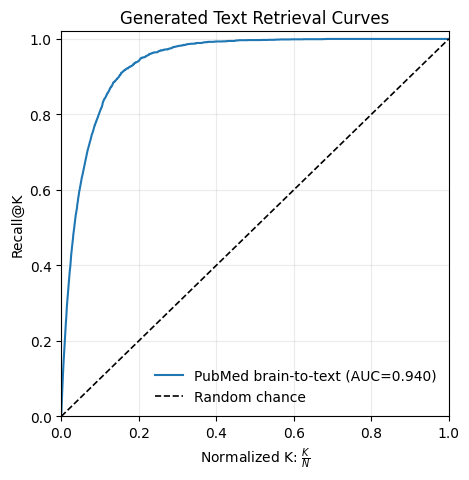

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
for (dataset, mode), curve_df in recall_curve_df.groupby(["dataset", "mode"]):
    auc_row = recall_auc_df[
        (recall_auc_df["dataset"] == dataset) &
        (recall_auc_df["mode"] == mode)
    ]
    auc = float(auc_row["generated_text_normalized_k_recall_curve_auc"].iloc[0]) if len(auc_row) else np.nan
    ax.plot(
        curve_df["normalized_k"],
        curve_df["recall_at_normalized_k"],
        label=f"PubMed brain-to-text (AUC={auc:.3f})",
    )
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
ax.set_ylabel("Recall@K")
ax.set_xlabel(r"Normalized K: $\frac{K}{N}$")
ax.set_title("Generated Text Retrieval Curves")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
# fig.tight_layout()
# plt.savefig(OUTPUT_DIR / "b2t_generated_text_normalized_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer

rng = np.random.default_rng(0)
plot_base = b2t_all.reset_index(drop=True).copy()

def as_normalized_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().float().numpy()
    else:
        x = np.asarray(x, dtype=np.float32)
    denom = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(denom, 1e-12, None)

def deranged_perm(n):
    if n < 2:
        return np.arange(n)
    for _ in range(100):
        perm = rng.permutation(n)
        if not np.any(perm == np.arange(n)):
            return perm
    return np.roll(np.arange(n), 1)

# Rebuild row-aligned projected embeddings if the earlier cached metric cell did
# not leave z_text/z_brain in memory.
needs_projected = (
    "z_text" not in globals()
    or "z_brain" not in globals()
    or len(torch.as_tensor(z_text)) != len(plot_base)
    or len(torch.as_tensor(z_brain)) != len(plot_base)
    or globals().get("projected_generation_source") != GENERATION_SOURCE
)
if needs_projected:
    if "text_latents" not in globals() or len(text_latents) != len(plot_base) or globals().get("text_latents_generation_source") != GENERATION_SOURCE:
        text_latents = encode_text_batched(nvlm, plot_base["generated"].astype(str).tolist(), batch_size=32)
        text_latents_generation_source = GENERATION_SOURCE
    z_text = project_text_latents_to_shared(nvlm, text_latents, batch_size=32)
    z_brain = project_brain_latents_to_shared(nvlm, brain_latents, batch_size=32)
    projected_generation_source = GENERATION_SOURCE

z_text_cpu = torch.as_tensor(z_text).detach().cpu().float()
z_brain_cpu = torch.as_tensor(z_brain).detach().cpu().float()

# Rebuild sentence embeddings if the semantic-similarity cell loaded only the
# saved diagonal scores. Keep final arrays on CPU and compute only row-wise dots.
embeddings_stale = (
    "g_emb" not in globals()
    or "t_emb" not in globals()
    or len(g_emb) != len(plot_base)
    or len(t_emb) != len(plot_base)
    or globals().get("semantic_embedding_generation_source") != GENERATION_SOURCE
)
if embeddings_stale:
    st_model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda" if torch.cuda.is_available() else "cpu")
    g_emb = st_model.encode(
        plot_base["generated"].astype(str).tolist(),
        batch_size=32,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    t_emb = st_model.encode(
        plot_base["gt_text"].astype(str).tolist(),
        batch_size=32,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    semantic_embedding_generation_source = GENERATION_SOURCE
else:
    g_emb = as_normalized_numpy(g_emb)
    t_emb = as_normalized_numpy(t_emb)

group_specs = []
for (dataset, mode), g in plot_base.groupby(["dataset", "mode"], sort=False):
    idx = g.index.to_numpy()
    group_specs.append((dataset, mode, idx, idx[deranged_perm(len(idx))]))

null_bert_cache = generation_cache_path("null_bert_f1_seed0.pt")
null_bert_f1 = None
if null_bert_cache.exists():
    cached = torch.load(null_bert_cache, map_location="cpu")
    if len(cached) == len(plot_base):
        null_bert_f1 = cached.float().numpy()

if null_bert_f1 is None:
    null_bert_f1 = np.full(len(plot_base), np.nan, dtype=np.float32)
    for dataset, mode, idx, null_idx in group_specs:
        if len(idx) < 2:
            null_bert_f1[idx] = plot_base.loc[idx, "bert_f1"].to_numpy(dtype=np.float32)
            continue
        _, _, f1 = bert_score(
            cands=plot_base.loc[idx, "generated"].astype(str).tolist(),
            refs=plot_base.loc[null_idx, "gt_text"].astype(str).tolist(),
            lang="en",
            model_type="microsoft/deberta-xlarge-mnli",
            batch_size=32,
            device="cuda" if torch.cuda.is_available() else "cpu",
            verbose=True,
        )
        null_bert_f1[idx] = f1.cpu().numpy()
    torch.save(torch.as_tensor(null_bert_f1), null_bert_cache)

rows = []
for dataset, mode, idx, null_idx in group_specs:
    idx_t = torch.as_tensor(idx, dtype=torch.long)
    null_idx_t = torch.as_tensor(null_idx, dtype=torch.long)

    # Matched metrics
    matched_nvlm = (z_text_cpu[idx_t] * z_brain_cpu[idx_t]).sum(dim=1).numpy()
    matched_sem = np.einsum("ij,ij->i", g_emb[idx], t_emb[idx])

    # Null metrics: generated text paired with another row's brain/reference
    null_nvlm = (z_text_cpu[idx_t] * z_brain_cpu[null_idx_t]).sum(dim=1).numpy()
    null_sem = np.einsum("ij,ij->i", g_emb[idx], t_emb[null_idx])
    matched_bert = plot_base.loc[idx, "bert_f1"].to_numpy()

    for kind, nvlm, bert, sem in [
        ("matched", matched_nvlm, matched_bert, matched_sem),
        ("null", null_nvlm, null_bert_f1[idx], null_sem),
    ]:
        for a, b, c in zip(nvlm, bert, sem):
            rows.append({
                "dataset": dataset,
                "mode": mode,
                "kind": kind,
                "nvlm_sim": a,
                "bert_f1": b,
                "sem_sim": c,
            })

plot_df = pd.DataFrame(rows)


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

nvlm_sim 0.2661546 0.019179013
bert_f1 0.55685216 0.51984006
sem_sim 0.46897495 0.40129003
contrastive null test: median_p= 0.03347840642785403 frac_p<0.05= 0.6149983260796786


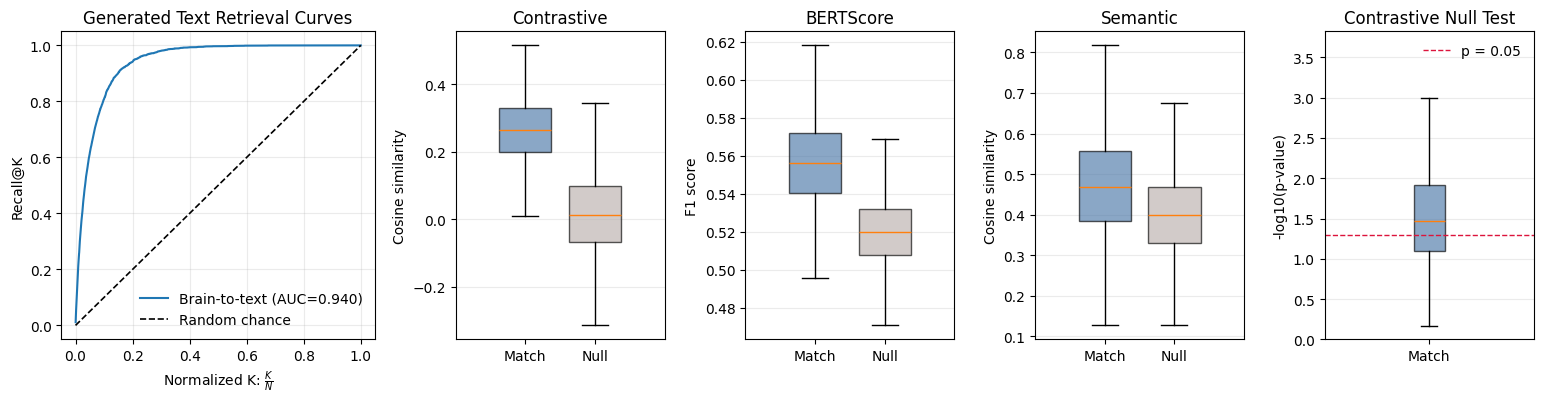

In [22]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Set B2T_PLOT_NEG_LOG10_P = False before this cell to plot raw p-values.
B2T_PLOT_NEG_LOG10_P = bool(globals().get("B2T_PLOT_NEG_LOG10_P", True))

if "plot_df" not in globals():
    raise RuntimeError("Run the matched/null metric cell first so plot_df exists.")
if "plot_base" not in globals():
    plot_base = b2t_all.reset_index(drop=True).copy()
if "z_text_cpu" not in globals() or "z_brain_cpu" not in globals():
    if "z_text" in globals() and "z_brain" in globals():
        z_text_cpu = torch.as_tensor(z_text).detach().cpu().float()
        z_brain_cpu = torch.as_tensor(z_brain).detach().cpu().float()
    else:
        raise RuntimeError("Run the contrastive embedding cell first so z_text/z_brain are available.")
if "group_specs" not in globals():
    rng = np.random.default_rng(0)
    def deranged_perm(n):
        if n < 2:
            return np.arange(n)
        for _ in range(100):
            perm = rng.permutation(n)
            if not np.any(perm == np.arange(n)):
                return perm
        return np.roll(np.arange(n), 1)
    group_specs = []
    for (dataset, mode), g in plot_base.groupby(["dataset", "mode"], sort=False):
        idx = g.index.to_numpy()
        group_specs.append((dataset, mode, idx, idx[deranged_perm(len(idx))]))


def _contrastive_null_test_df():
    rows = []
    for dataset, mode, idx, _ in group_specs:
        n = len(idx)
        if n < 2:
            for row_idx in idx:
                rows.append({"dataset": dataset, "mode": mode, "row_index": int(row_idx), "contrastive_null_p": np.nan})
            continue
        idx_t = torch.as_tensor(idx, dtype=torch.long)
        scores = z_text_cpu[idx_t] @ z_brain_cpu[idx_t].T
        matched = scores.diag()
        null_ge = (scores >= matched[:, None]).sum(dim=1).cpu().numpy() - 1
        pvals = (1.0 + null_ge) / float(n)
        for row_idx, pval in zip(idx, pvals):
            rows.append({"dataset": dataset, "mode": mode, "row_index": int(row_idx), "contrastive_null_p": float(pval)})
    return pd.DataFrame(rows)


def _pvalue_transform(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if B2T_PLOT_NEG_LOG10_P:
        return -np.log10(np.clip(values, 1e-300, None))
    return values


b2t_contrastive_null_df = _contrastive_null_test_df()

fig, axes = plt.subplots(
    1,
    5,
    figsize=(19, 4),
    gridspec_kw={"width_ratios": [3, 2, 2, 2, 2], "wspace": 0.35},
)

ax = axes[0]
for (dataset, mode), curve_df in recall_curve_df.groupby(["dataset", "mode"]):
    auc_row = recall_auc_df[
        (recall_auc_df["dataset"] == dataset) &
        (recall_auc_df["mode"] == mode)
    ]
    auc = float(auc_row["generated_text_normalized_k_recall_curve_auc"].iloc[0]) if len(auc_row) else np.nan
    ax.plot(
        curve_df["normalized_k"],
        curve_df["recall_at_normalized_k"],
        label=f"Brain-to-text (AUC={auc:.3f})",
    )
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
ax.set_ylabel("Recall@K")
ax.set_xlabel(r"Normalized K: $\frac{K}{N}$")
ax.set_title("Generated Text Retrieval Curves")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

metric_specs = [
    ("nvlm_sim", "Contrastive", "Cosine similarity"),
    ("bert_f1", "BERTScore", "F1 score"),
    ("sem_sim", "Semantic", "Cosine similarity"),
]

metric_groups = {}
for ax, (metric, title, ylab) in zip(axes[1:4], metric_specs):
    groups, labels = [], []
    for dataset, g in plot_df.groupby("dataset", sort=False):
        groups.append(g[g["kind"] == "matched"][metric].dropna().values)
        labels.append("Match")
        groups.append(g[g["kind"] == "null"][metric].dropna().values)
        labels.append("Null")

    bp = ax.boxplot(groups, positions=[0.4, 0.6], tick_labels=labels, showfliers=False, patch_artist=True)
    for patch, label in zip(bp["boxes"], labels):
        patch.set_facecolor("#4C78A8" if "match" in label.lower() else "#BAB0AC")
        patch.set_alpha(0.65)

    metric_groups[metric] = groups
    print(metric, groups[0].mean(), groups[1].mean())
    ax.set_title(title)
    ax.set_xlim(0.2, 0.8)
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.25)

ax = axes[4]
p_groups, p_labels = [], []
for (dataset, mode), g in b2t_contrastive_null_df.groupby(["dataset", "mode"], sort=False):
    p_groups.append(_pvalue_transform(g["contrastive_null_p"].to_numpy()))
    p_labels.append(str(dataset))

if p_groups and any(len(g) for g in p_groups):
    bp = ax.boxplot(p_groups, tick_labels=["Match"], showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#4C78A8")
        patch.set_alpha(0.65)
    thresh = -np.log10(0.05) if B2T_PLOT_NEG_LOG10_P else 0.05
    ax.axhline(thresh, color="crimson", linestyle="--", linewidth=1, label="p = 0.05")
    ax.legend(frameon=False)#, loc="upper right")
    if B2T_PLOT_NEG_LOG10_P:
        ymax = max(thresh * 1.2, max((np.nanmax(g) for g in p_groups if len(g)), default=thresh) * 1.1)
        ax.set_ylim(0, ymax)
    else:
        finite_p = b2t_contrastive_null_df["contrastive_null_p"].dropna()
        ax.set_ylim(0, min(1.0, max(0.1, float(finite_p.max()) * 1.1)))
else:
    ax.text(0.5, 0.5, "No finite contrastive null p-values", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_ylim(0, 1)
ax.set_title("Contrastive Null Test")
ax.set_ylabel("-log10(p-value)" if B2T_PLOT_NEG_LOG10_P else "p-value")
ax.grid(axis="y", alpha=0.25)

finite_p = b2t_contrastive_null_df["contrastive_null_p"].dropna()
if len(finite_p):
    print(
        "contrastive null test:",
        "median_p=", float(finite_p.median()),
        "frac_p<0.05=", float((finite_p < 0.05).mean()),
    )

plt.savefig("brain_to_text_metrics_pubmed.svg", bbox_inches="tight")
plt.show()



In [ ]:
import numpy as np
import pandas as pd
import mpmath as mp

mp.mp.dps = 100  # arbitrary precision decimal digits

def welch_ttest_with_mp_p(x, y, digits=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx, ny = len(x), len(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)

    se2 = vx / nx + vy / ny
    t = (mx - my) / np.sqrt(se2)

    df = se2**2 / ((vx / nx)**2 / (nx - 1) + (vy / ny)**2 / (ny - 1))

    # Two-sided Student t p-value:
    # p = I_{df / (df + t^2)}(df / 2, 1 / 2)
    df_mp = mp.mpf(str(df))
    t_mp = mp.mpf(str(abs(t)))
    x_mp = df_mp / (df_mp + t_mp**2)

    p_mp = mp.betainc(df_mp / 2, mp.mpf("0.5"), 0, x_mp, regularized=True)

    log10_p = mp.log10(p_mp)
    exponent = mp.floor(log10_p)
    mantissa = mp.power(10, log10_p - exponent)

    p_sci = f"{float(mantissa):.{digits}f}e{int(exponent)}"

    return float(t), float(df), float(log10_p), p_sci


metrics = ["nvlm_sim", "bert_f1", "sem_sim"]

rows = []
for metric in metrics:
    matched = plot_df.loc[plot_df["kind"].eq("matched"), metric].dropna().to_numpy()
    null = plot_df.loc[plot_df["kind"].eq("null"), metric].dropna().to_numpy()

    t_stat, df, log10_p, p_sci = welch_ttest_with_mp_p(matched, null)

    rows.append({
        "metric": metric,
        "n_matched": len(matched),
        "n_null": len(null),
        "matched_mean": matched.mean(),
        "null_mean": null.mean(),
        "mean_diff": matched.mean() - null.mean(),
        "matched_std": matched.std(ddof=1),
        "null_std": null.std(ddof=1),
        "t": t_stat,
        "df": df,
        "log10_p": log10_p,
        "p_sci": p_sci,
    })

ttest_df = pd.DataFrame(rows)
ttest_df

,metric,n_matched,n_null,matched_mean,null_mean,mean_diff,matched_std,null_std,t,df,log10_p,p_sci
0,nvlm_sim,2987,2987,0.266155,0.019179,0.246976,0.091506,0.126301,86.544969,5443.600255,-1024.793230,1.610e-1025
1,bert_f1,2987,2987,0.556852,0.519840,0.037012,0.023382,0.018370,68.029398,5655.216759,-736.073505,8.443e-737
2,sem_sim,2987,2987,0.468975,0.401290,0.067685,0.122294,0.105148,22.936307,5840.733466,-110.821105,1.510e-111
